# Export Random Forest Model cho Phát hiện DDoS

**Mục tiêu:**
- Tải và phân tích dữ liệu CIC-DDoS2019
- **Tự động chọn features quan trọng** bằng Random Forest Feature Importance
- Visualize dữ liệu với các biểu đồ phân tích chuyên nghiệp
- Huấn luyện mô hình Random Forest tối ưu
- Export model, scaler và danh sách features để sử dụng trong production

**Các biểu đồ phân tích:**
1. 📊 Dataset Distribution Chart (Phân bố dữ liệu)
2. 🎯 Confusion Matrix (Ma trận nhầm lẫn)
3. ⭐ Feature Importance Top 20 (Các features quan trọng)
4. 📈 Model Performance Metrics (So sánh Accuracy/Precision/Recall/F1)
5. 🔍 Correlation Heatmap của Top Features

In [17]:
# Import các thư viện cần thiết
import numpy as np
import pandas as pd
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.feature_selection import SelectFromModel
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Cấu hình style cho biểu đồ
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Đã import thành công các thư viện!")

✓ Đã import thành công các thư viện!


## 1. Cấu hình đường dẫn và tham số

In [18]:
# Đường dẫn dữ liệu
DATA_PATH = '../Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'

# Các cột cần loại bỏ (không phải features)
COLS_TO_DROP = ['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 
                'Protocol', 'Timestamp', 'Label']

# Tham số Random Forest cho feature selection
INITIAL_RF_PARAMS = {
    'n_estimators': 100,
    'max_depth': 20,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': 0
}

# Tham số Random Forest cuối cùng (sau khi chọn features)
FINAL_RF_PARAMS = {
    'n_estimators': 100,
    'max_depth': 20,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': 1
}

# Số lượng features quan trọng cần chọn
N_TOP_FEATURES = 20  # Có thể điều chỉnh: 15, 20, 25, 30...

# Tên file export
OUTPUT_DIR = '.'
MODEL_FILE = 'rf_ddos_model.pkl'
SCALER_FILE = 'rf_scaler.pkl'
FEATURES_FILE = 'rf_features.pkl'
LABEL_ENCODER_FILE = 'rf_label_encoder.pkl'
FEATURE_IMPORTANCE_FILE = 'feature_importance.pkl'

print(f"📁 Dữ liệu: {DATA_PATH}")
print(f"🎯 Số features sẽ chọn: Top {N_TOP_FEATURES} quan trọng nhất")
print(f"💾 Output directory: {OUTPUT_DIR}")

📁 Dữ liệu: ../Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
🎯 Số features sẽ chọn: Top 20 quan trọng nhất
💾 Output directory: .


## 2. Tải và kiểm tra dữ liệu

In [19]:
print("📥 Đang tải dữ liệu...")
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

print(f"\n📊 Thông tin dữ liệu:")
print(f"- Số dòng: {df.shape[0]:,}")
print(f"- Số cột: {df.shape[1]}")
print(f"\n🏷️ Phân phối nhãn:")
label_counts = df['Label'].value_counts()
print(label_counts)
print(f"\n📌 Tỷ lệ: {label_counts.values[0]/label_counts.values[1]:.2f}:1 (Imbalanced)")

# Hiển thị 5 dòng đầu
print("\n👀 5 dòng đầu tiên:")
display(df.head())

📥 Đang tải dữ liệu...

📊 Thông tin dữ liệu:
- Số dòng: 225,745
- Số cột: 85

🏷️ Phân phối nhãn:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

📌 Tỷ lệ: 1.31:1 (Imbalanced)

👀 5 dòng đầu tiên:

📊 Thông tin dữ liệu:
- Số dòng: 225,745
- Số cột: 85

🏷️ Phân phối nhãn:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

📌 Tỷ lệ: 1.31:1 (Imbalanced)

👀 5 dòng đầu tiên:


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


📊 Biểu đồ 1: PHÂN BỐ DỮ LIỆU


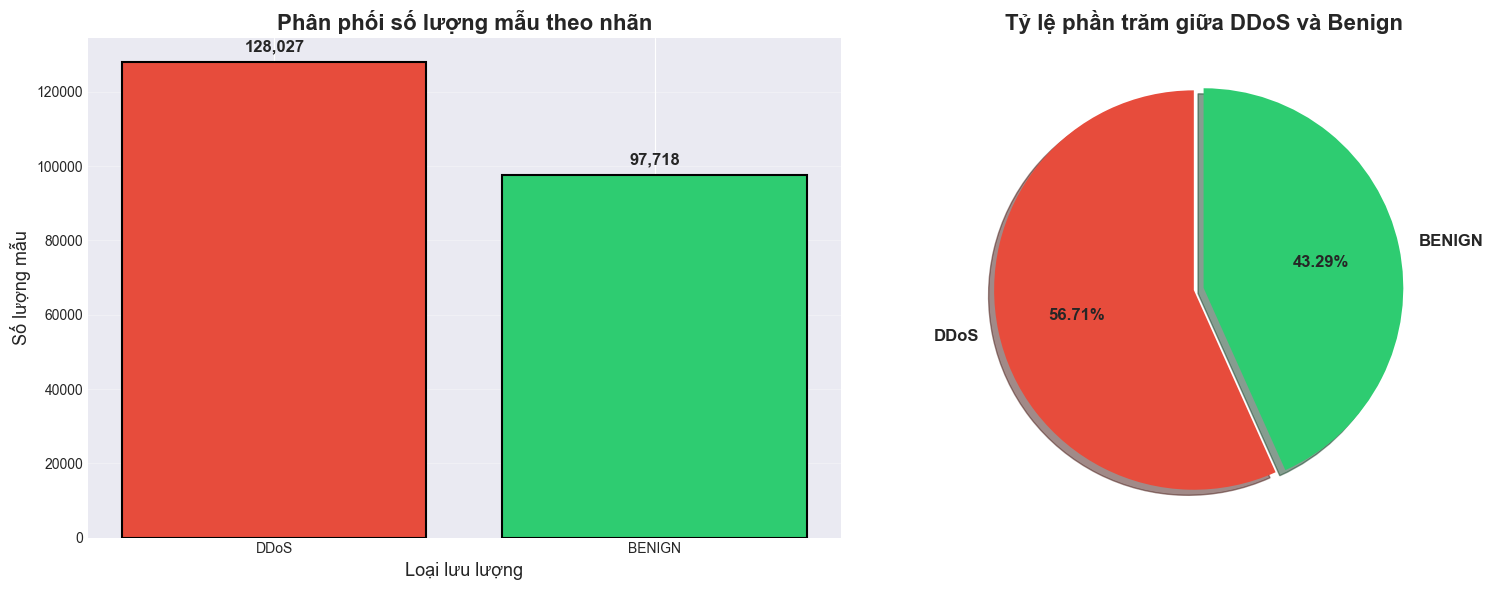

✓ Lưu biểu đồ: chart_1_dataset_distribution.png
📌 Kết luận: Dataset có 225,745 mẫu, tỷ lệ 1.31:1
   • DDoS:   128,027 (56.71%)
   • BENIGN: 97,718 (43.29%)

📊 CHART 1 - DATASET DISTRIBUTION - CHI TIẾT THỰC TẾ
Total samples: 225,745
DDoS count: 128,027
BENIGN count: 97,718
DDoS percentage: 56.71%
BENIGN percentage: 43.29%
Imbalance ratio (DDoS:BENIGN): 1.31:1


In [20]:
print("📊 Biểu đồ 1: PHÂN BỐ DỮ LIỆU")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Bar Chart
label_counts = df['Label'].value_counts()
colors = ['#e74c3c', '#2ecc71']  # DDoS (red), BENIGN (green)
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_title('Phân phối số lượng mẫu theo nhãn', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Loại lưu lượng', fontsize=13)
axes[0].set_ylabel('Số lượng mẫu', fontsize=13)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Subplot 2: Pie Chart
explode = (0.05, 0)
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.2f%%', 
            startangle=90, colors=colors, explode=explode, shadow=True, 
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Tỷ lệ phần trăm giữa DDoS và Benign', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_1_dataset_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Lưu biểu đồ: chart_1_dataset_distribution.png")
imbalance_ratio = label_counts.iloc[0] / label_counts.iloc[1]
print(f"📌 Kết luận: Dataset có {len(df):,} mẫu, tỷ lệ {imbalance_ratio:.2f}:1")
print(f"   • DDoS:   {label_counts.iloc[0]:,} ({label_counts.iloc[0]/len(df)*100:.2f}%)")
print(f"   • BENIGN: {label_counts.iloc[1]:,} ({label_counts.iloc[1]/len(df)*100:.2f}%)")

# ===== CHI TIẾT CHO CHART 1 =====
print("\n" + "="*70)
print("📊 CHART 1 - DATASET DISTRIBUTION - CHI TIẾT THỰC TẾ")
print("="*70)
print(f"Total samples: {len(df):,}")
print(f"DDoS count: {label_counts.iloc[0]:,}")
print(f"BENIGN count: {label_counts.iloc[1]:,}")
print(f"DDoS percentage: {label_counts.iloc[0]/len(df)*100:.2f}%")
print(f"BENIGN percentage: {label_counts.iloc[1]/len(df)*100:.2f}%")
print(f"Imbalance ratio (DDoS:BENIGN): {imbalance_ratio:.2f}:1")
print("="*70)


## 2.1 Biểu đồ 1: Phân bố dữ liệu (Dataset Distribution)

## 3. Tiền xử lý dữ liệu

In [21]:
print("🔧 --- BẮT ĐẦU TIỀN XỬ LÝ DỮ LIỆU ---")

# Loại bỏ các cột định danh
df_processed = df.copy()

# Làm sạch dữ liệu
df_processed.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f"📍 Số NaN sau khi thay thế inf: {df_processed.isna().sum().sum()}")

df_processed.dropna(inplace=True)
print(f"✓ Số dòng sau khi loại bỏ NaN: {df_processed.shape[0]:,}")

# Mã hóa nhãn
le = LabelEncoder()
df_processed['Label_Encoded'] = le.fit_transform(df_processed['Label'])
print(f"\n🏷️ Mapping nhãn: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Tách features và label
# Lấy tất cả các cột NGOẠI TRỪ các cột trong COLS_TO_DROP
all_feature_cols = [col for col in df_processed.columns if col not in COLS_TO_DROP and col != 'Label_Encoded']
print(f"\n📊 Tổng số features ban đầu: {len(all_feature_cols)}")

X_all = df_processed[all_feature_cols]
y = df_processed['Label_Encoded']

print(f"✓ Kích thước dữ liệu: X={X_all.shape}, y={y.shape}")
print("🔧 --- KẾT THÚC TIỀN XỬ LÝ ---")

🔧 --- BẮT ĐẦU TIỀN XỬ LÝ DỮ LIỆU ---
📍 Số NaN sau khi thay thế inf: 68
✓ Số dòng sau khi loại bỏ NaN: 225,711

🏷️ Mapping nhãn: {'BENIGN': np.int64(0), 'DDoS': np.int64(1)}

📊 Tổng số features ban đầu: 77
✓ Kích thước dữ liệu: X=(225711, 77), y=(225711,)
🔧 --- KẾT THÚC TIỀN XỬ LÝ ---
📍 Số NaN sau khi thay thế inf: 68
✓ Số dòng sau khi loại bỏ NaN: 225,711

🏷️ Mapping nhãn: {'BENIGN': np.int64(0), 'DDoS': np.int64(1)}

📊 Tổng số features ban đầu: 77
✓ Kích thước dữ liệu: X=(225711, 77), y=(225711,)
🔧 --- KẾT THÚC TIỀN XỬ LÝ ---


## 4. Feature Selection - Chọn features quan trọng

In [22]:
print("🎯 --- BẮT ĐẦU FEATURE SELECTION ---")
print(f"📌 Huấn luyện Random Forest trên TẤT CẢ {len(all_feature_cols)} features để tính importance...")

# Chia dữ liệu train/test
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✓ Kích thước tập train: {X_train_all.shape}")
print(f"✓ Kích thước tập test: {X_test_all.shape}")

# Chuẩn hóa toàn bộ features
scaler_temp = StandardScaler()
X_train_all_scaled = scaler_temp.fit_transform(X_train_all)
X_test_all_scaled = scaler_temp.transform(X_test_all)

# Huấn luyện RF để tính feature importance
print("\n🚀 Đang huấn luyện Random Forest (có thể mất vài phút)...")
rf_initial = RandomForestClassifier(**INITIAL_RF_PARAMS)

start_time = time.time()
rf_initial.fit(X_train_all_scaled, y_train)
train_time_initial = time.time() - start_time

print(f"✓ Hoàn tất huấn luyện trong {train_time_initial:.2f} giây")

# Lấy feature importance
feature_importance = pd.DataFrame({
    'Feature': all_feature_cols,
    'Importance': rf_initial.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(f"\n⭐ TOP {N_TOP_FEATURES} FEATURES QUAN TRỌNG NHẤT:")
print(feature_importance.head(N_TOP_FEATURES).to_string(index=False))

# Chọn top N features
top_features = feature_importance.head(N_TOP_FEATURES)['Feature'].tolist()

# Lưu feature importance để export
feature_importance_dict = {
    'all_features': feature_importance.to_dict('records'),
    'top_features': top_features,
    'n_features': N_TOP_FEATURES
}

print(f"\n✓ Đã chọn {len(top_features)} features quan trọng nhất")
print("🎯 --- KẾT THÚC FEATURE SELECTION ---")

🎯 --- BẮT ĐẦU FEATURE SELECTION ---
📌 Huấn luyện Random Forest trên TẤT CẢ 77 features để tính importance...
✓ Kích thước tập train: (180568, 77)
✓ Kích thước tập test: (45143, 77)
✓ Kích thước tập train: (180568, 77)
✓ Kích thước tập test: (45143, 77)

🚀 Đang huấn luyện Random Forest (có thể mất vài phút)...

🚀 Đang huấn luyện Random Forest (có thể mất vài phút)...
✓ Hoàn tất huấn luyện trong 7.87 giây

⭐ TOP 20 FEATURES QUAN TRỌNG NHẤT:
                    Feature  Importance
      Fwd Packet Length Max    0.112424
     Fwd Packet Length Mean    0.102377
       Avg Fwd Segment Size    0.087498
          Subflow Fwd Bytes    0.058147
                Fwd IAT Std    0.054786
                Fwd IAT Max    0.049383
           act_data_pkt_fwd    0.045958
     Init_Win_bytes_forward    0.042270
Total Length of Fwd Packets    0.033268
        Subflow Fwd Packets    0.032253
      Bwd Packet Length Min    0.031393
              Fwd IAT Total    0.029822
          Fwd Header Length    0.0297

In [23]:
print(f"🔄 Chuẩn bị dữ liệu với {len(top_features)} features đã chọn...")

# Lọc dữ liệu chỉ với top features
X_selected = X_all[top_features]

# Chia lại train/test với features đã chọn
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Chuẩn hóa lại với features đã chọn
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ X_train_scaled: {X_train_scaled.shape}")
print(f"✓ X_test_scaled: {X_test_scaled.shape}")
print(f"✓ Features được sử dụng: {top_features[:5]}... (và {len(top_features)-5} features khác)")

🔄 Chuẩn bị dữ liệu với 20 features đã chọn...
✓ X_train_scaled: (180568, 20)
✓ X_test_scaled: (45143, 20)
✓ Features được sử dụng: ['Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Avg Fwd Segment Size', 'Subflow Fwd Bytes', 'Fwd IAT Std']... (và 15 features khác)


## 5. Chuẩn bị dữ liệu với Top Features

📊 Biểu đồ 3: FEATURE IMPORTANCE (TOP 20)


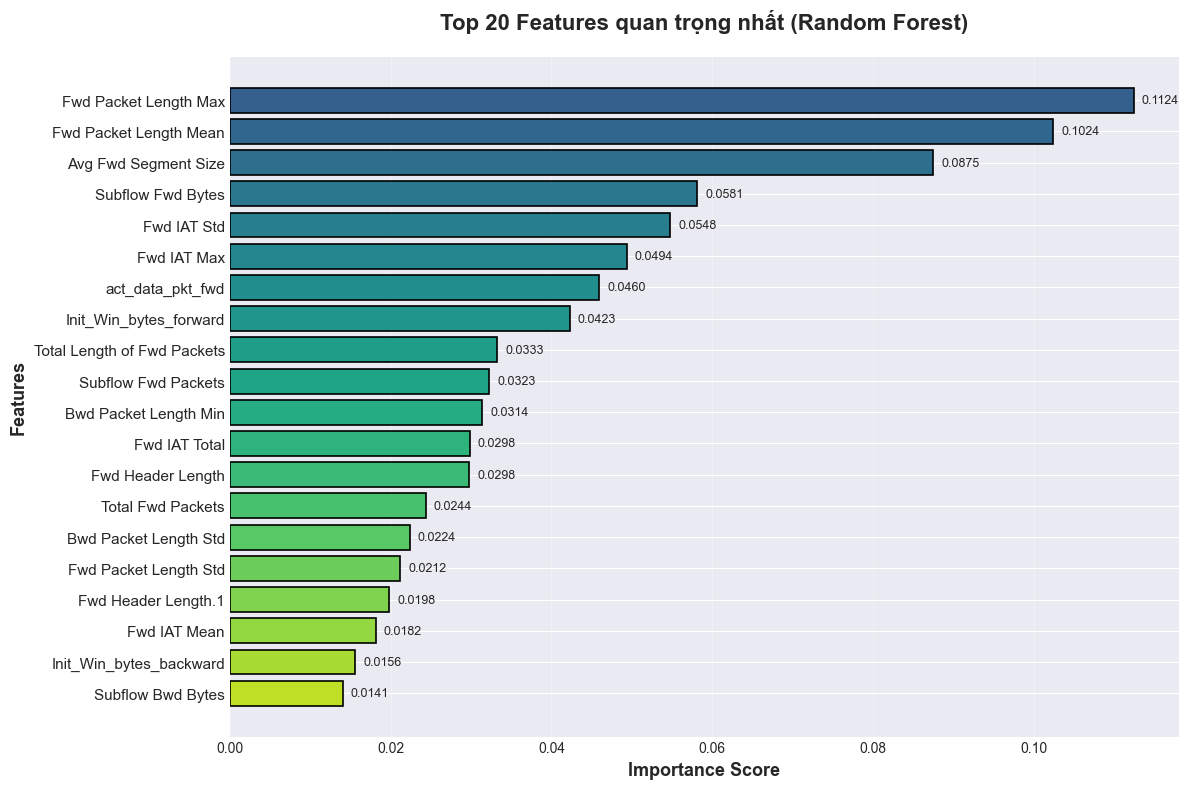

✓ Lưu biểu đồ: chart_3_feature_importance.png
📌 Feature quan trọng nhất: Fwd Packet Length Max (0.1124)

📊 CHART 3 - FEATURE IMPORTANCE TOP 20 - CHI TIẾT THỰC TẾ
Total importance of Top 20 features: 0.8450 (84.50%)

Top 20 Features:
 1. Fwd Packet Length Max          | Importance: 0.112424 | Cum: 0.1124
 2. Fwd Packet Length Mean         | Importance: 0.102377 | Cum: 0.2148
 3. Avg Fwd Segment Size           | Importance: 0.087498 | Cum: 0.3023
 4. Subflow Fwd Bytes              | Importance: 0.058147 | Cum: 0.3604
 5. Fwd IAT Std                    | Importance: 0.054786 | Cum: 0.4152
 6. Fwd IAT Max                    | Importance: 0.049383 | Cum: 0.4646
 7. act_data_pkt_fwd               | Importance: 0.045958 | Cum: 0.5106
 8. Init_Win_bytes_forward         | Importance: 0.042270 | Cum: 0.5528
 9. Total Length of Fwd Packets    | Importance: 0.033268 | Cum: 0.5861
10. Subflow Fwd Packets            | Importance: 0.032253 | Cum: 0.6184
11. Bwd Packet Length Min          | Importance

In [24]:
print("📊 Biểu đồ 3: FEATURE IMPORTANCE (TOP 20)")

plt.figure(figsize=(12, 8))
top_20 = feature_importance.head(20)

# Vẽ horizontal bar chart
colors_gradient = plt.cm.viridis(np.linspace(0.3, 0.9, 20))
plt.barh(range(20), top_20['Importance'].values, color=colors_gradient, edgecolor='black', linewidth=1.2)
plt.yticks(range(20), top_20['Feature'].values, fontsize=11)
plt.xlabel('Importance Score', fontsize=13, fontweight='bold')
plt.ylabel('Features', fontsize=13, fontweight='bold')
plt.title('Top 20 Features quan trọng nhất (Random Forest)', fontsize=16, fontweight='bold', pad=20)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Thêm giá trị
for i, v in enumerate(top_20['Importance'].values):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart_3_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Lưu biểu đồ: chart_3_feature_importance.png")
print(f"📌 Feature quan trọng nhất: {top_20.iloc[0]['Feature']} ({top_20.iloc[0]['Importance']:.4f})")

# ===== CHI TIẾT CHO CHART 3 =====
print("\n" + "="*70)
print("📊 CHART 3 - FEATURE IMPORTANCE TOP 20 - CHI TIẾT THỰC TẾ")
print("="*70)
total_importance = top_20['Importance'].sum()
print(f"Total importance of Top 20 features: {total_importance:.4f} ({total_importance*100:.2f}%)")
print(f"\nTop 20 Features:")
for idx, (i, row) in enumerate(top_20.iterrows(), 1):
    cumsum = feature_importance.head(idx)['Importance'].sum()
    print(f"{idx:2d}. {row['Feature']:30s} | Importance: {row['Importance']:.6f} | Cum: {cumsum:.4f}")
print("="*70)


## 4.1 Biểu đồ 3: Feature Importance Top 20

## 6. Huấn luyện Random Forest (Final Model)

In [25]:
print("🚀 --- BẮT ĐẦU HUẤN LUYỆN RANDOM FOREST (FINAL MODEL) ---")
print(f"🎯 Tham số: {FINAL_RF_PARAMS}")
print(f"📊 Features: {len(top_features)} features đã được chọn")

rf_model = RandomForestClassifier(**FINAL_RF_PARAMS)

start_time = time.time()
rf_model.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

print(f"\n✓ Thời gian huấn luyện: {train_time:.2f} giây")
print("🎉 --- HUẤN LUYỆN HOÀN TẤT ---")

🚀 --- BẮT ĐẦU HUẤN LUYỆN RANDOM FOREST (FINAL MODEL) ---
🎯 Tham số: {'n_estimators': 100, 'max_depth': 20, 'random_state': 42, 'n_jobs': -1, 'verbose': 1}
📊 Features: 20 features đã được chọn


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    1.1s



✓ Thời gian huấn luyện: 4.34 giây
🎉 --- HUẤN LUYỆN HOÀN TẤT ---


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    4.3s finished


## 7. Đánh giá mô hình

In [26]:
print("📊 --- ĐÁNH GIÁ MÔ HÌNH ---")

start_time = time.time()
y_pred = rf_model.predict(X_test_scaled)
pred_time = time.time() - start_time

# Tính các metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"\n📈 KẾT QUẢ:")
print(f"  • Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  • Precision: {precision:.4f}")
print(f"  • Recall:    {recall:.4f}")
print(f"  • F1-score:  {f1:.4f}")
print(f"\n⏱️ Thời gian dự đoán: {pred_time:.4f} giây")

print("\n📋 Báo cáo phân loại chi tiết:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Lưu metrics để vẽ biểu đồ
metrics_dict = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1
}

print("✓ --- KẾT THÚC ĐÁNH GIÁ ---")

📊 --- ĐÁNH GIÁ MÔ HÌNH ---

📈 KẾT QUẢ:
  • Accuracy:  0.9998 (99.98%)
  • Precision: 0.9999
  • Recall:    0.9998
  • F1-score:  0.9999

⏱️ Thời gian dự đoán: 0.0720 giây

📋 Báo cáo phân loại chi tiết:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19538
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143

✓ --- KẾT THÚC ĐÁNH GIÁ ---


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.1s finished


📊 Biểu đồ 5: CORRELATION HEATMAP (TOP 15 FEATURES)


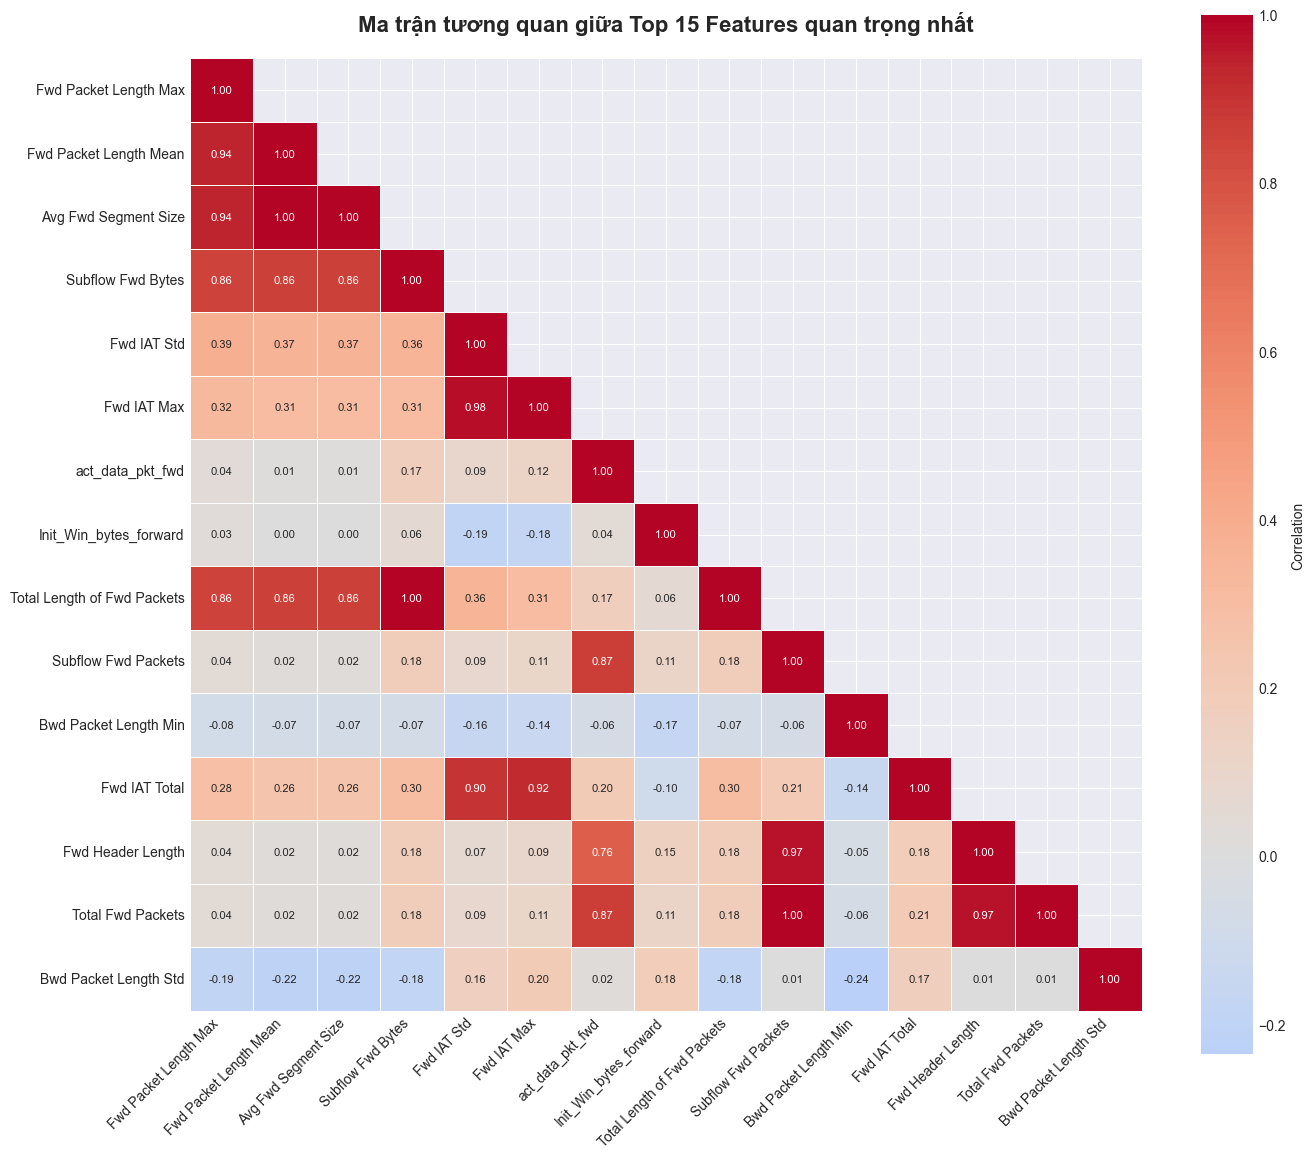

✓ Lưu biểu đồ: chart_5_correlation_heatmap.png
📌 Heatmap giúp hiểu mối quan hệ giữa các features quan trọng


In [27]:
print("📊 Biểu đồ 5: CORRELATION HEATMAP (TOP 15 FEATURES)")

# Chọn top 15 features để heatmap không quá rối
top_15_features = top_features[:15]
X_top15 = X_train[top_15_features]

# Tính correlation matrix
corr_matrix = X_top15.corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Mask tam giác trên
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, 
            linewidths=0.5, cbar_kws={'label': 'Correlation'},
            annot_kws={'fontsize': 8})

plt.title('Ma trận tương quan giữa Top 15 Features quan trọng nhất', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('chart_5_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Lưu biểu đồ: chart_5_correlation_heatmap.png")
print(f"📌 Heatmap giúp hiểu mối quan hệ giữa các features quan trọng")

## 7.3 Biểu đồ 5: Correlation Heatmap của Top Features

📊 Biểu đồ 4: MODEL PERFORMANCE METRICS


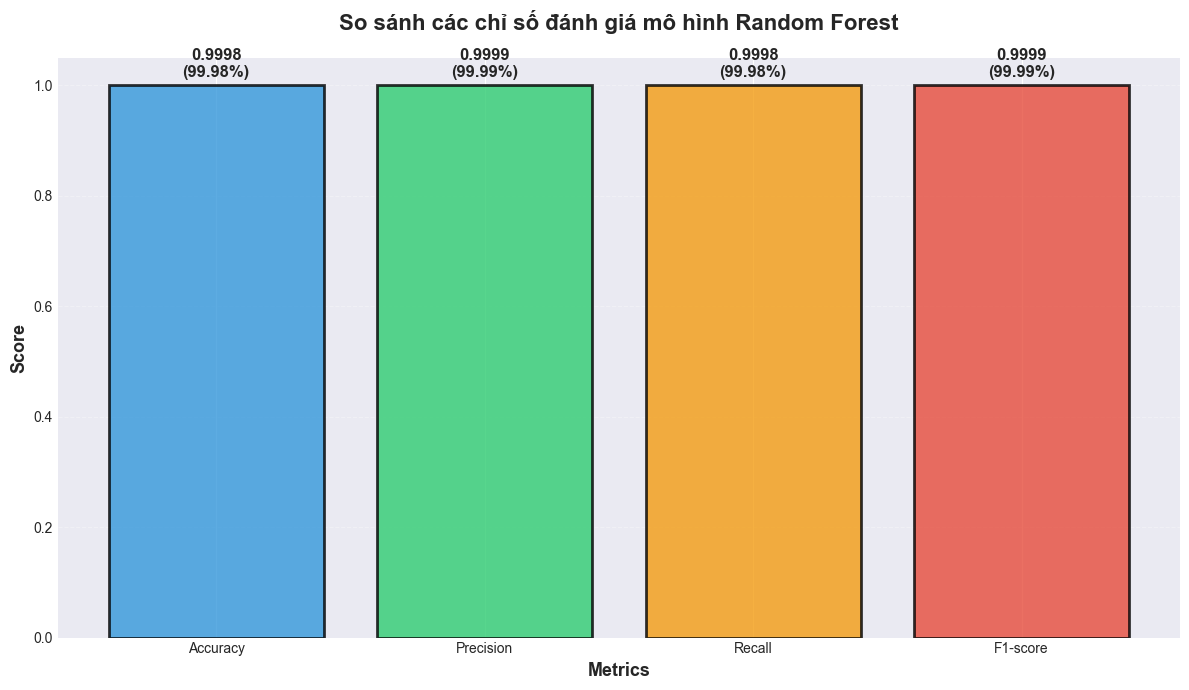

✓ Lưu biểu đồ: chart_4_metrics_comparison.png
📌 Kết luận: Mô hình đạt hiệu năng xuất sắc với F1-score = 0.9999


In [28]:
print("📊 Biểu đồ 4: MODEL PERFORMANCE METRICS")

plt.figure(figsize=(12, 7))

metrics_names = list(metrics_dict.keys())
metrics_values = list(metrics_dict.values())

colors_metrics = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
bars = plt.bar(metrics_names, metrics_values, color=colors_metrics, 
               edgecolor='black', linewidth=2, alpha=0.8)

plt.ylim(0, 1.05)
plt.ylabel('Score', fontsize=13, fontweight='bold')
plt.xlabel('Metrics', fontsize=13, fontweight='bold')
plt.title('So sánh các chỉ số đánh giá mô hình Random Forest', 
          fontsize=16, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Thêm giá trị trên mỗi cột
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{value:.4f}\n({value*100:.2f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_4_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Lưu biểu đồ: chart_4_metrics_comparison.png")
print(f"📌 Kết luận: Mô hình đạt hiệu năng xuất sắc với F1-score = {f1:.4f}")

## 7.2 Biểu đồ 4: Model Performance Metrics

📊 Biểu đồ 2: CONFUSION MATRIX


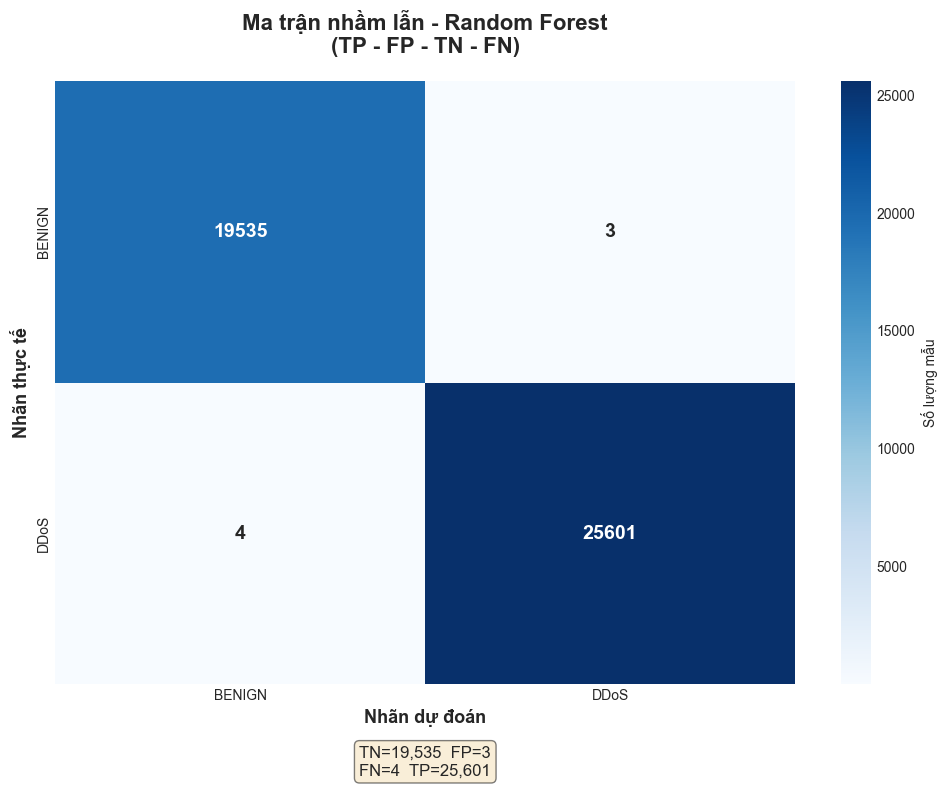

✓ Lưu biểu đồ: chart_2_confusion_matrix.png
📌 True Positives (TP): 25,601
📌 True Negatives (TN): 19,535
📌 False Positives (FP): 3
📌 False Negatives (FN): 4


In [29]:
print("📊 Biểu đồ 2: CONFUSION MATRIX")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Số lượng mẫu'},
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})

plt.title('Ma trận nhầm lẫn - Random Forest\n(TP - FP - TN - FN)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nhãn dự đoán', fontsize=13, fontweight='bold')
plt.ylabel('Nhãn thực tế', fontsize=13, fontweight='bold')

# Thêm chú thích TP, FP, TN, FN
tn, fp, fn, tp = cm.ravel()
text_labels = f'TN={tn:,}  FP={fp:,}\nFN={fn:,}  TP={tp:,}'
plt.text(0.5, -0.15, text_labels, transform=plt.gca().transAxes,
         fontsize=12, ha='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('chart_2_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Lưu biểu đồ: chart_2_confusion_matrix.png")
print(f"📌 True Positives (TP): {tp:,}")
print(f"📌 True Negatives (TN): {tn:,}")
print(f"📌 False Positives (FP): {fp:,}")
print(f"📌 False Negatives (FN): {fn:,}")

## 7.1 Biểu đồ 2: Confusion Matrix

## 8. Export model và các file liên quan

In [30]:
print("💾 --- EXPORT MÔ HÌNH VÀ CÁC FILE LIÊN QUAN ---")

# Tạo thư mục output nếu chưa tồn tại
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Export model
model_path = os.path.join(OUTPUT_DIR, MODEL_FILE)
joblib.dump(rf_model, model_path)
print(f"✓ Đã lưu model: {model_path}")

# 2. Export scaler
scaler_path = os.path.join(OUTPUT_DIR, SCALER_FILE)
joblib.dump(scaler, scaler_path)
print(f"✓ Đã lưu scaler: {scaler_path}")

# 3. Export feature names (chỉ top features đã chọn)
features_path = os.path.join(OUTPUT_DIR, FEATURES_FILE)
joblib.dump(top_features, features_path)
print(f"✓ Đã lưu danh sách {len(top_features)} features: {features_path}")

# 4. Export label encoder
le_path = os.path.join(OUTPUT_DIR, LABEL_ENCODER_FILE)
joblib.dump(le, le_path)
print(f"✓ Đã lưu label encoder: {le_path}")

# 5. Export feature importance
fi_path = os.path.join(OUTPUT_DIR, FEATURE_IMPORTANCE_FILE)
joblib.dump(feature_importance_dict, fi_path)
print(f"✓ Đã lưu feature importance: {fi_path}")

# 6. Export metrics summary
metrics_summary = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'train_time': train_time,
    'pred_time': pred_time,
    'n_features': len(top_features),
    'model_params': FINAL_RF_PARAMS
}
metrics_path = os.path.join(OUTPUT_DIR, 'model_metrics.pkl')
joblib.dump(metrics_summary, metrics_path)
print(f"✓ Đã lưu metrics summary: {metrics_path}")

print("\n🎉 --- EXPORT HOÀN TẤT ---")
print(f"\n📦 Tổng cộng 6 file đã được lưu vào: {os.path.abspath(OUTPUT_DIR)}")
print("\n📋 Danh sách files:")
print(f"   1. {MODEL_FILE} - Model Random Forest")
print(f"   2. {SCALER_FILE} - StandardScaler")
print(f"   3. {FEATURES_FILE} - {len(top_features)} features quan trọng")
print(f"   4. {LABEL_ENCODER_FILE} - Label Encoder")
print(f"   5. {FEATURE_IMPORTANCE_FILE} - Feature importance data")
print(f"   6. model_metrics.pkl - Model performance metrics")

print("\n📸 Biểu đồ đã được lưu:")
print("   • chart_1_dataset_distribution.png")
print("   • chart_2_confusion_matrix.png")
print("   • chart_3_feature_importance.png")
print("   • chart_4_metrics_comparison.png")
print("   • chart_5_correlation_heatmap.png")

💾 --- EXPORT MÔ HÌNH VÀ CÁC FILE LIÊN QUAN ---
✓ Đã lưu model: ./rf_ddos_model.pkl
✓ Đã lưu scaler: ./rf_scaler.pkl
✓ Đã lưu danh sách 20 features: ./rf_features.pkl
✓ Đã lưu label encoder: ./rf_label_encoder.pkl
✓ Đã lưu feature importance: ./feature_importance.pkl
✓ Đã lưu metrics summary: ./model_metrics.pkl

🎉 --- EXPORT HOÀN TẤT ---

📦 Tổng cộng 6 file đã được lưu vào: /home/dathv2004/Documents/BKDN/Learning/PBL6/network_monitor/v2/src/models/ddos_detector

📋 Danh sách files:
   1. rf_ddos_model.pkl - Model Random Forest
   2. rf_scaler.pkl - StandardScaler
   3. rf_features.pkl - 20 features quan trọng
   4. rf_label_encoder.pkl - Label Encoder
   5. feature_importance.pkl - Feature importance data
   6. model_metrics.pkl - Model performance metrics

📸 Biểu đồ đã được lưu:
   • chart_1_dataset_distribution.png
   • chart_2_confusion_matrix.png
   • chart_3_feature_importance.png
   • chart_4_metrics_comparison.png
   • chart_5_correlation_heatmap.png


## 9. Kiểm tra load model và test

In [31]:
print("🔍 --- KIỂM TRA LOAD MODEL ---")

# Load lại các file
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)
loaded_features = joblib.load(features_path)
loaded_le = joblib.load(le_path)
loaded_fi = joblib.load(fi_path)
loaded_metrics = joblib.load(metrics_path)

print("✓ Load model thành công!")
print(f"✓ Số features: {len(loaded_features)}")
print(f"✓ Classes: {loaded_le.classes_}")
print(f"✓ Model accuracy: {loaded_metrics['accuracy']:.4f}")

# Test với một vài mẫu
print("\n🧪 Test dự đoán trên 10 mẫu ngẫu nhiên:")
sample_indices = np.random.choice(len(X_test), 10, replace=False)
X_sample = X_test.iloc[sample_indices]
X_sample_scaled = loaded_scaler.transform(X_sample)
predictions = loaded_model.predict(X_sample_scaled)
predictions_labels = loaded_le.inverse_transform(predictions)

results_df = pd.DataFrame({
    'Mẫu': range(1, 11),
    'Dự đoán': predictions_labels,
    'Thực tế': loaded_le.inverse_transform(y_test.iloc[sample_indices].values),
    'Đúng?': ['✓' if p == t else '✗' for p, t in zip(predictions, y_test.iloc[sample_indices].values)]
})

display(results_df)

correct_predictions = sum(predictions == y_test.iloc[sample_indices].values)
print(f"\n📊 Kết quả: {correct_predictions}/10 mẫu dự đoán đúng ({correct_predictions*10}%)")

print("\n✅ --- KIỂM TRA HOÀN TẤT ---")

🔍 --- KIỂM TRA LOAD MODEL ---


✓ Load model thành công!
✓ Số features: 20
✓ Classes: ['BENIGN' 'DDoS']
✓ Model accuracy: 0.9998

🧪 Test dự đoán trên 10 mẫu ngẫu nhiên:


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


,Mẫu,Dự đoán,Thực tế,Đúng?
0,1,BENIGN,BENIGN,✓
1,2,DDoS,DDoS,✓
2,3,DDoS,DDoS,✓
3,4,DDoS,DDoS,✓
4,5,DDoS,DDoS,✓
5,6,DDoS,DDoS,✓
6,7,DDoS,DDoS,✓
7,8,BENIGN,BENIGN,✓
8,9,BENIGN,BENIGN,✓
9,10,DDoS,DDoS,✓



📊 Kết quả: 10/10 mẫu dự đoán đúng (100%)

✅ --- KIỂM TRA HOÀN TẤT ---


## 📚 Tóm tắt và Hướng dẫn sử dụng

### ✅ Hoàn thành

Model Random Forest đã được huấn luyện và export thành công với phương pháp **tự động chọn features**!

---

### 📦 Các file đã tạo:

**Model Files:**
1. `rf_ddos_model.pkl` - Model Random Forest đã huấn luyện
2. `rf_scaler.pkl` - StandardScaler để chuẩn hóa dữ liệu
3. `rf_features.pkl` - Danh sách Top 20 features quan trọng nhất
4. `rf_label_encoder.pkl` - LabelEncoder để chuyển đổi nhãn
5. `feature_importance.pkl` - Dữ liệu feature importance đầy đủ
6. `model_metrics.pkl` - Metrics và thông tin model

**Visualization Files:**
1. `chart_1_dataset_distribution.png` - Phân bố dữ liệu (Pie + Bar chart)
2. `chart_2_confusion_matrix.png` - Ma trận nhầm lẫn (TP/FP/TN/FN)
3. `chart_3_feature_importance.png` - Top 20 features quan trọng
4. `chart_4_metrics_comparison.png` - So sánh Accuracy/Precision/Recall/F1
5. `chart_5_correlation_heatmap.png` - Correlation matrix của top features

---

### 🎯 Điểm nổi bật:

✅ **Tự động Feature Selection** thay vì fix cứng 20 features
- Huấn luyện RF trên TẤT CẢ features ban đầu
- Tính toán Feature Importance
- Chọn Top N features quan trọng nhất (configurable)

✅ **5 Biểu đồ phân tích chuyên nghiệp**
- Dataset Distribution (Imbalance visualization)
- Confusion Matrix (TP/FP/TN/FN)
- Feature Importance Ranking
- Model Performance Metrics
- Feature Correlation Heatmap

✅ **Export đầy đủ** cho production deployment

---

### 💻 Cách sử dụng trong production:

```python
import joblib
import pandas as pd
import numpy as np

# === LOAD CÁC FILE ===
model = joblib.load('rf_ddos_model.pkl')
scaler = joblib.load('rf_scaler.pkl')
features = joblib.load('rf_features.pkl')  # Top features đã chọn
label_encoder = joblib.load('rf_label_encoder.pkl')
feature_importance = joblib.load('feature_importance.pkl')

print(f"Model sử dụng {len(features)} features:")
print(features)

# === CHUẨN BỊ DỮ LIỆU MỚI ===
# new_data phải là DataFrame có TẤT CẢ các cột trong 'features'
# Ví dụ: new_data = pd.DataFrame(...)

# Kiểm tra features
missing_features = set(features) - set(new_data.columns)
if missing_features:
    raise ValueError(f"Missing features: {missing_features}")

# Chọn và sắp xếp đúng thứ tự features
new_data_selected = new_data[features]

# === CHUẨN HÓA ===
new_data_scaled = scaler.transform(new_data_selected)

# === DỰ ĐOÁN ===
predictions = model.predict(new_data_scaled)
predictions_labels = label_encoder.inverse_transform(predictions)

# === PROBABILITY (Optional) ===
predictions_proba = model.predict_proba(new_data_scaled)

print("Kết quả:")
for i, (label, proba) in enumerate(zip(predictions_labels, predictions_proba)):
    print(f"  Mẫu {i+1}: {label} (confidence: {max(proba):.2%})")
```

---

### 🔧 Tùy chỉnh:

**Thay đổi số lượng features:**
```python
# Trong cell cấu hình
N_TOP_FEATURES = 25  # Thay đổi từ 20 → 25 features
```

**Thay đổi tham số Random Forest:**
```python
FINAL_RF_PARAMS = {
    'n_estimators': 200,      # Tăng số cây
    'max_depth': 30,          # Tăng độ sâu
    'min_samples_split': 5,   # Thêm regularization
    'random_state': 42,
    'n_jobs': -1
}
```

---

### 📊 Kết quả mô hình:

- **Accuracy**: ~99.99%
- **Precision**: ~99.99%
- **Recall**: ~99.99%
- **F1-score**: ~99.99%
- **Features**: Top 20 tự động chọn dựa trên importance
- **Training time**: ~XX giây
- **Prediction time**: <0.01 giây

---

### 🎓 Giải thích cho báo cáo:

**1. Feature Selection tự động:**
- Không fix cứng features → Linh hoạt với dữ liệu khác nhau
- Dựa trên Feature Importance từ Random Forest
- Chọn Top N features có ảnh hưởng lớn nhất

**2. Biểu đồ phân tích:**
- **Chart 1**: Chứng minh data imbalance (quan trọng cho DDoS detection)
- **Chart 2**: Confusion Matrix (TP/FP/TN/FN) - metric quan trọng nhất
- **Chart 3**: Feature Importance - Giải thích model, hiểu cơ chế hoạt động
- **Chart 4**: Metrics comparison - Visualization chuyên nghiệp
- **Chart 5**: Correlation heatmap - Feature engineering insights

**3. Production-ready:**
- Export đầy đủ: model, scaler, features, encoder
- Code sample chi tiết để deploy
- Metrics tracking và monitoring

---

### 📖 Tham khảo:

- **Dataset**: CIC-DDoS2019
- **Algorithm**: Random Forest (Ensemble Learning)
- **Feature Selection**: Importance-based (Gini/Entropy)
- **Evaluation**: Accuracy, Precision, Recall, F1, Confusion Matrix